# Load Experiment Data

Reads all XDF files from `experiment_data/` and converts each LSL stream into a pandas DataFrame.

## LSL Stream Channels

Each XDF file contains up to 7 LSL streams produced by the Seesaw Unity project:

| Stream | Channels | Description |
|---|---|---|
| `Unity.GameManagerState` | `is_pause` (0/1), `leading_player_id` (+1 or -1), `play_score` (int) | Game state: pause flag, which player leads the current block, cumulative score |
| `Unity.Position.Player1` | `pos_x`, `pos_y`, `pos_z` | World position of Player 1 (server-side player) |
| `Unity.Position.Player2` | `pos_x`, `pos_y`, `pos_z` | World position of Player 2 (client-side player) |
| `Unity.Position.Target1` | `pos_x`, `pos_y`, `pos_z` | World position of Target 1 (belongs to Player 1) |
| `Unity.Position.Target2` | `pos_x`, `pos_y`, `pos_z` | World position of Target 2 (belongs to Player 2) |
| `Unity.Position.Ball` | `pos_x`, `pos_y`, `pos_z` | World position of the seesaw ball |
| `Unity.ClientPlayerDistance` | `player_shift_distance` | Per-frame movement delta from client player input (BasePlayerSpeed × direction × acceleration) |

In [1]:
import os
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyxdf

## Configuration

In [2]:
DATA_DIR = Path("experiment_data")

# Column name mapping for each stream type
STREAM_COLUMNS = {
    "Unity.GameManagerState": ["is_pause", "leading_player_id", "play_score"],
    "Unity.Position": ["pos_x", "pos_y", "pos_z"],
    "Unity.ClientPlayerDistance": ["player_shift_distance"],
}

## Helper Functions

In [3]:
def get_columns_for_stream(stream_name: str) -> list[str]:
    """Return column names for a given LSL stream name."""
    if stream_name.startswith("Unity.Position."):
        return STREAM_COLUMNS["Unity.Position"]
    return STREAM_COLUMNS.get(stream_name, [])


def parse_filename(filename: str) -> dict:
    """Extract date, dyad ID, and session number from filename.

    Expected format: 20260413_1330_Session1.xdf
    """
    stem = Path(filename).stem
    parts = stem.split("_")
    return {
        "date": parts[0],
        "dyad": parts[1],
        "session": int(parts[2].replace("Session", "")),
    }


def stream_to_dataframe(stream: dict) -> pd.DataFrame:
    """Convert a single XDF stream dict to a pandas DataFrame."""
    stream_name = stream["info"]["name"][0]
    columns = get_columns_for_stream(stream_name)

    if not columns:
        # Unknown stream — use generic column names
        n_channels = int(stream["info"]["channel_count"][0])
        columns = [f"ch_{i}" for i in range(n_channels)]

    df = pd.DataFrame(stream["time_series"], columns=columns)
    df.insert(0, "timestamp", stream["time_stamps"])
    return df


def load_xdf_to_dataframes(filepath: Path) -> dict[str, pd.DataFrame]:
    """Load an XDF file and return a dict mapping stream names to DataFrames."""
    data, _ = pyxdf.load_xdf(str(filepath))
    result = {}
    for stream in data:
        stream_name = stream["info"]["name"][0]
        result[stream_name] = stream_to_dataframe(stream)
    return result

## Load All XDF Files

The result is a nested dictionary: `all_data[dyad][session][stream_name]` → `DataFrame`

In [4]:
xdf_files = sorted(DATA_DIR.glob("*.xdf"))
print(f"Found {len(xdf_files)} XDF files")

all_data = {}

for filepath in xdf_files:
    meta = parse_filename(filepath.name)
    dyad = meta["dyad"]
    session = meta["session"]

    streams = load_xdf_to_dataframes(filepath)

    if dyad not in all_data:
        all_data[dyad] = {}
    all_data[dyad][session] = streams

    stream_summary = ", ".join(f"{name} ({len(df)} rows)" for name, df in streams.items())
    print(f"  {filepath.name}: {stream_summary}")

print(f"\nLoaded {len(all_data)} dyads: {sorted(all_data.keys())}")

Found 18 XDF files
  20260413_1330_Session1.xdf: Unity.Position.Target2 (17232 rows), Unity.Position.Player1 (17232 rows), Unity.Position.Ball (17232 rows), Unity.GameManagerState (17232 rows), Unity.ClientPlayerDistance (18956 rows), Unity.Position.Player2 (17231 rows), Unity.Position.Target1 (17232 rows)
  20260413_1330_Session2.xdf: Unity.GameManagerState (7204 rows), Unity.Position.Target1 (7204 rows), Unity.Position.Player1 (7203 rows), Unity.Position.Player2 (7203 rows), Unity.ClientPlayerDistance (7204 rows), Unity.Position.Target2 (7203 rows)
  20260413_1330_Session3.xdf: Unity.Position.Ball (15708 rows), Unity.Position.Player2 (15708 rows), Unity.Position.Player1 (15708 rows), Unity.Position.Target2 (15708 rows), Unity.GameManagerState (15707 rows), Unity.Position.Target1 (15708 rows), Unity.ClientPlayerDistance (15880 rows)
  20260413_1355_Session1.xdf: Unity.Position.Player1 (15610 rows), Unity.Position.Ball (15610 rows), Unity.ClientPlayerDistance (16029 rows), Unity.Positi

## Inspect a Sample DataFrame

Pick the first dyad's first session to show what the data looks like.

In [5]:
first_dyad = sorted(all_data.keys())[0]
first_session = sorted(all_data[first_dyad].keys())[0]
streams = all_data[first_dyad][first_session]

print(f"Dyad: {first_dyad}, Session: {first_session}")
print(f"Streams: {list(streams.keys())}\n")

for name, df in streams.items():
    print(f"--- {name} ---")
    print(f"Shape: {df.shape}")
    duration = df["timestamp"].iloc[-1] - df["timestamp"].iloc[0]
    print(f"Duration: {duration:.1f}s")
    print(df.head(3))
    print()

Dyad: 1330, Session: 1
Streams: ['Unity.Position.Target2', 'Unity.Position.Player1', 'Unity.Position.Ball', 'Unity.GameManagerState', 'Unity.ClientPlayerDistance', 'Unity.Position.Player2', 'Unity.Position.Target1']

--- Unity.Position.Target2 ---
Shape: (17232, 4)
Duration: 344.6s
       timestamp  pos_x  pos_y  pos_z
0  345162.464406    7.5    3.0    0.0
1  345162.484406    7.5    3.0    0.0
2  345162.504406    7.5    3.0    0.0

--- Unity.Position.Player1 ---
Shape: (17232, 4)
Duration: 344.6s
       timestamp  pos_x  pos_y  pos_z
0  345162.464343   -7.0    0.0    0.0
1  345162.484343   -7.0    0.0    0.0
2  345162.504344   -7.0    0.0    0.0

--- Unity.Position.Ball ---
Shape: (17232, 4)
Duration: 344.6s
       timestamp  pos_x  pos_y  pos_z
0  345162.464402    0.0    1.0    0.0
1  345162.484402    0.0    1.0    0.0
2  345162.504402    0.0    1.0    0.0

--- Unity.GameManagerState ---
Shape: (17232, 4)
Duration: 344.6s
       timestamp  is_pause  leading_player_id  play_score
0  34

## Build Flat Summary Table

One row per file with recording metadata for quick overview.

In [6]:
summary_rows = []

for dyad in sorted(all_data.keys()):
    for session in sorted(all_data[dyad].keys()):
        streams = all_data[dyad][session]
        # Use the first stream's timestamps for duration
        first_stream = next(iter(streams.values()))
        duration = first_stream["timestamp"].iloc[-1] - first_stream["timestamp"].iloc[0]
        summary_rows.append({
            "dyad": dyad,
            "session": session,
            "n_streams": len(streams),
            "duration_s": round(duration, 1),
            "has_ball": "Unity.Position.Ball" in streams,
        })

summary_df = pd.DataFrame(summary_rows)
summary_df

,dyad,session,n_streams,duration_s,has_ball
0,1330,1,7,344.6,True
1,1330,2,6,144.1,False
2,1330,3,7,314.1,True
3,1355,1,7,312.2,True
4,1355,2,6,117.6,False
5,1355,3,7,314.9,True
6,1420,1,7,410.6,True
7,1420,2,6,139.1,False
8,1420,3,7,311.9,True
9,1440,1,7,314.0,True


## Ball Movement

For each session with ball tracking data: three aligned subplots showing ball position (X/Y), rolling standard deviation, and leading player ID over time.

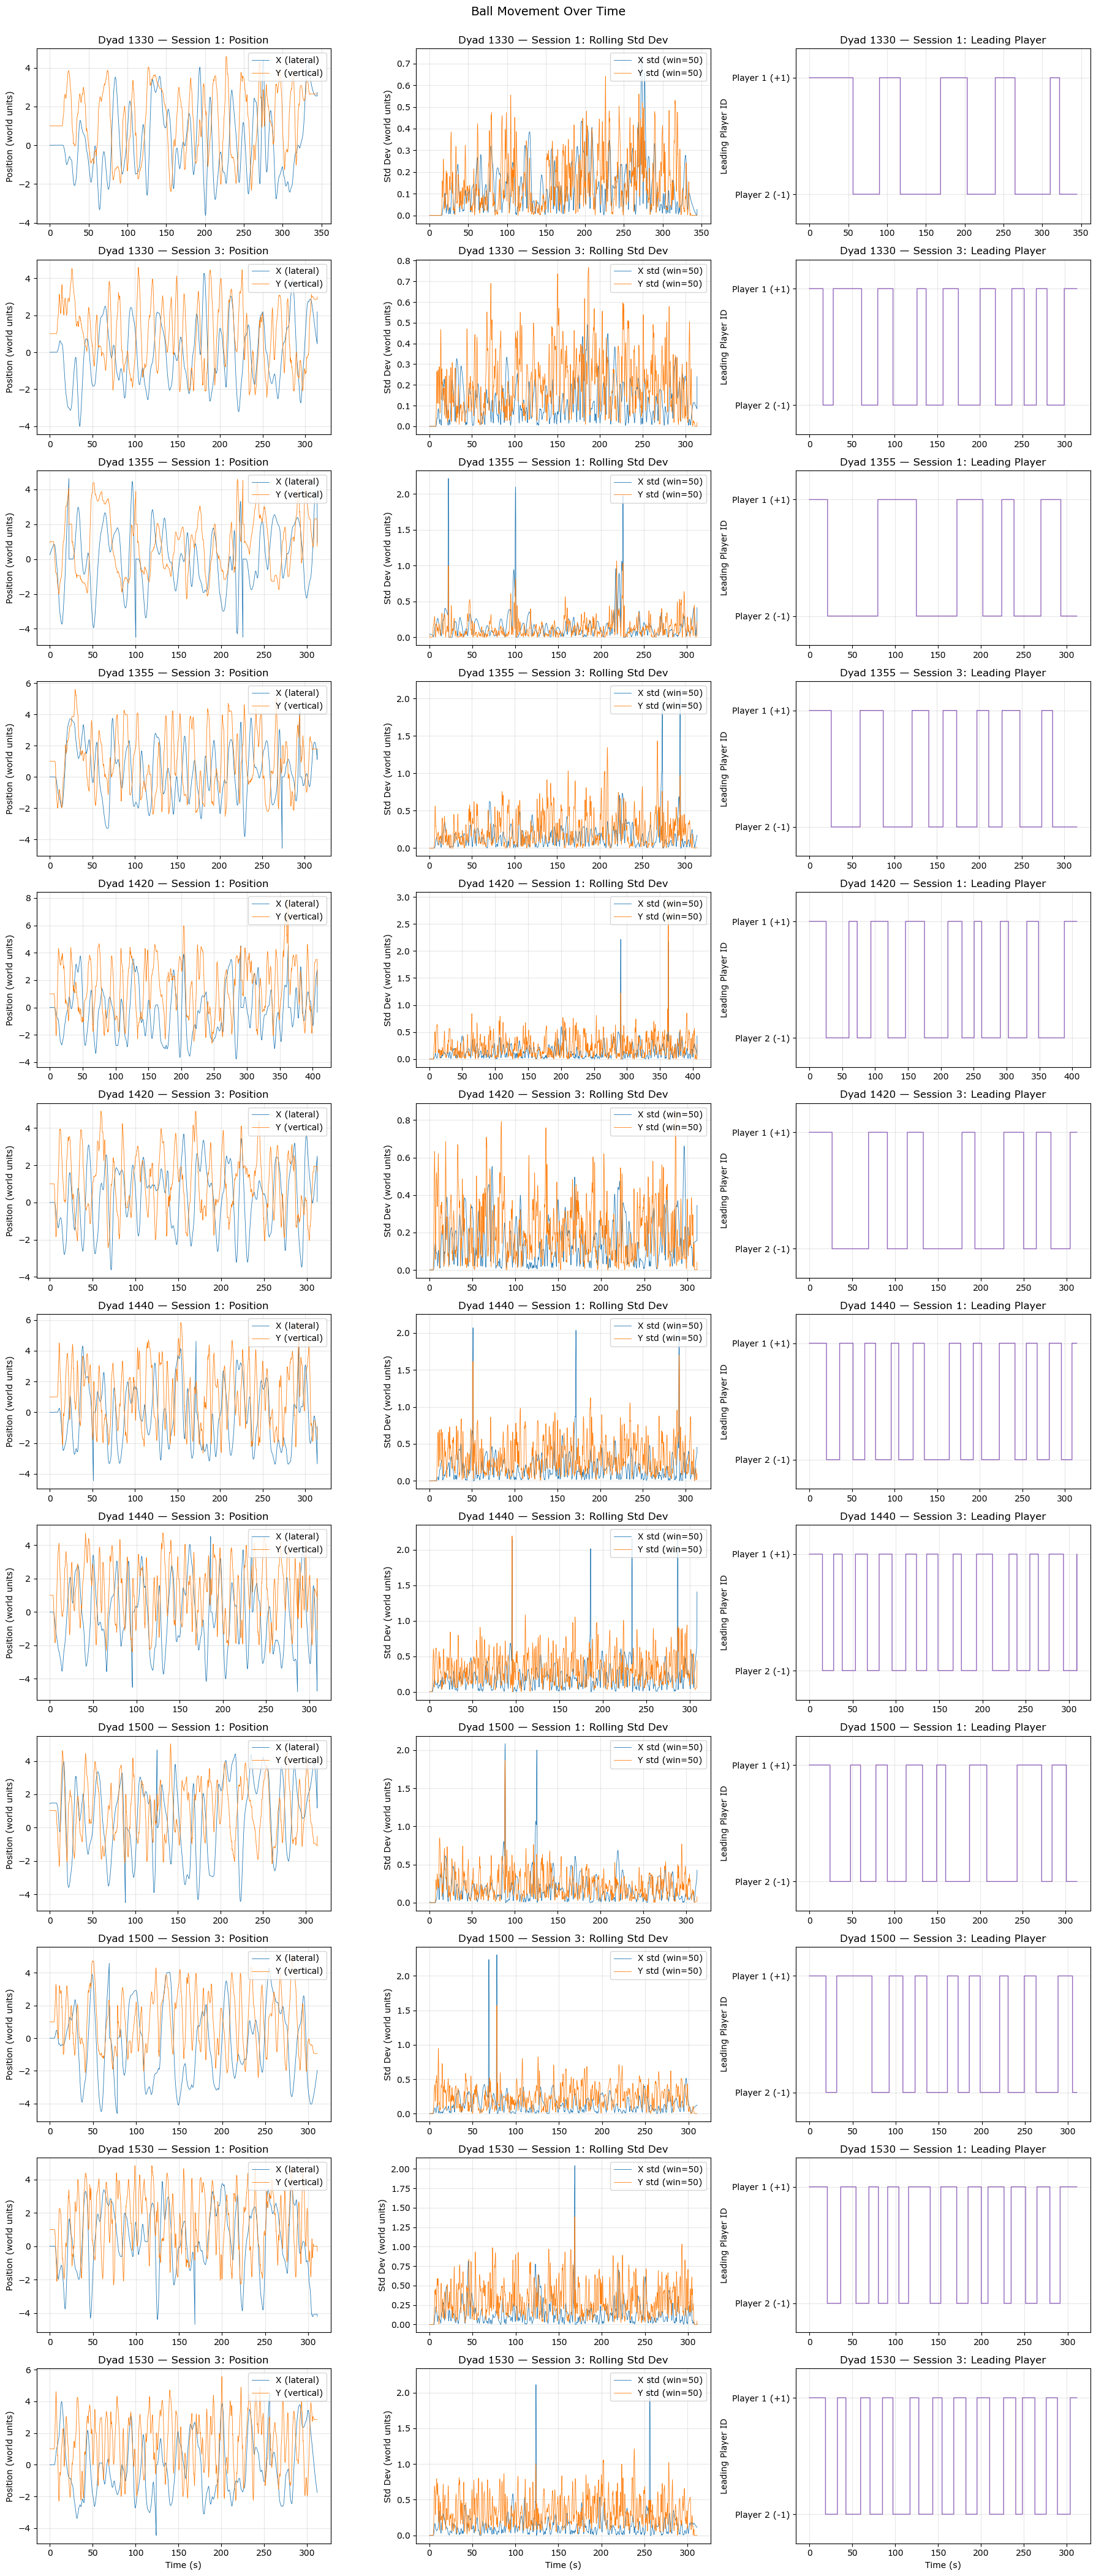

In [7]:
ball_stream = "Unity.Position.Ball"
state_stream = "Unity.GameManagerState"
WINDOW = 50  # rolling window size for standard deviation

# Collect all (dyad, session) pairs that have ball data
ball_recordings = [
    (dyad, session)
    for dyad in sorted(all_data)
    for session in sorted(all_data[dyad])
    if ball_stream in all_data[dyad][session]
]

n_plots = len(ball_recordings)
fig, axes = plt.subplots(n_plots, 3, figsize=(18, 3.5 * n_plots), sharex=False)
if n_plots == 1:
    axes = [axes]

for row, (dyad, session) in zip(axes, ball_recordings):
    streams = all_data[dyad][session]
    df_ball = streams[ball_stream]
    t_ball = df_ball["timestamp"] - df_ball["timestamp"].iloc[0]

    ax_pos, ax_std, ax_leader = row

    # 1) Position plot
    ax_pos.plot(t_ball, df_ball["pos_x"], label="X (lateral)", linewidth=0.6)
    ax_pos.plot(t_ball, df_ball["pos_y"], label="Y (vertical)", linewidth=0.6)
    ax_pos.set_title(f"Dyad {dyad} — Session {session}: Position")
    ax_pos.set_ylabel("Position (world units)")
    ax_pos.legend(loc="upper right")
    ax_pos.grid(True, alpha=0.3)

    # 2) Rolling standard deviation plot
    x_std = df_ball["pos_x"].rolling(WINDOW, center=True).std()
    y_std = df_ball["pos_y"].rolling(WINDOW, center=True).std()
    ax_std.plot(t_ball, x_std, label=f"X std (win={WINDOW})", linewidth=0.6)
    ax_std.plot(t_ball, y_std, label=f"Y std (win={WINDOW})", linewidth=0.6)
    ax_std.set_title(f"Dyad {dyad} — Session {session}: Rolling Std Dev")
    ax_std.set_ylabel("Std Dev (world units)")
    ax_std.legend(loc="upper right")
    ax_std.grid(True, alpha=0.3)

    # 3) Leading player ID plot
    df_state = streams[state_stream]
    t_state = df_state["timestamp"] - df_state["timestamp"].iloc[0]
    ax_leader.step(t_state, df_state["leading_player_id"], where="post",
                   linewidth=1.0, color="tab:purple")
    ax_leader.set_title(f"Dyad {dyad} — Session {session}: Leading Player")
    ax_leader.set_ylabel("Leading Player ID")
    ax_leader.set_yticks([-1, 1])
    ax_leader.set_yticklabels(["Player 2 (-1)", "Player 1 (+1)"])
    ax_leader.set_ylim(-1.5, 1.5)
    ax_leader.grid(True, alpha=0.3)

for ax in axes[-1]:
    ax.set_xlabel("Time (s)")

fig.suptitle("Ball Movement Over Time", fontsize=14, y=1.0)
fig.tight_layout()
plt.show()